In [46]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test (1).csv
Saving train.csv to train (1).csv


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer

In [48]:
# Считываем тренировочные и тестовые данные
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(f"Train dataset shape: {train_df.shape}")
print(f"Test dataset shape: {test_df.shape}")


Train dataset shape: (751, 214)
Test dataset shape: (250, 211)


Тренировочный датасет содержит:
- 751 строку - это количество объектов в нашем наборе данных
- 214 столбцов - это количество характеристик(признаков) для каждого объекта

Тестовый датасет содержит 250 строк и 211 признаков

In [49]:
train_df.head()

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


In [50]:
test_df.head()

,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,13.761882,13.761882,0.121946,-0.962625,0.770057,30.580645,450.541,432.397,450.070799,...,1,0,0,0,0,0,0,1,0,0
1,1,13.224489,13.224489,0.066132,-1.801871,0.278628,25.687500,448.380,428.220,448.100561,...,0,0,0,0,0,0,0,0,0,0
2,2,6.191528,6.191528,0.445278,0.445278,0.657472,55.384615,179.307,158.139,179.167400,...,0,0,0,0,0,0,0,0,0,0
3,3,14.061236,14.061236,0.054870,-6.660336,0.564307,23.464286,410.289,397.185,410.086525,...,0,0,0,0,0,0,0,0,0,0
4,4,12.790378,12.790378,0.320463,-1.642616,0.696213,22.000000,280.279,268.183,280.073559,...,0,0,0,0,0,0,0,0,0,0


In [51]:
# Сохраняем index для submission
test_index = test_df["index"]

# Удаляем index из train и test
train_df = train_df.drop("index", axis=1)
test_df = test_df.drop("index", axis=1)

In [52]:
train_df.head()
train_df.info()
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.2 MB


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,...,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.0,751.000000,751.000000,751.000000
mean,204.544021,577.426098,89.153313,10.860070,10.860070,0.180064,-0.971890,0.577938,29.588010,352.407345,...,0.055925,0.013316,0.010652,0.001332,0.001332,0.054594,0.0,0.069241,0.182423,0.006658
std,370.367937,641.515163,788.882198,3.347314,3.347314,0.169163,1.594491,0.214190,12.713195,129.071212,...,0.272400,0.114699,0.102728,0.036491,0.036491,0.227337,0.0,0.254033,1.227468,0.081377
min,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.545455,110.156000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,13.222351,99.998894,1.500000,8.921032,8.921032,0.048473,-1.333831,0.442842,18.306020,266.252000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,44.069306,376.580899,4.000000,12.197500,12.197500,0.121372,-0.419485,0.636477,29.281250,319.129000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,206.787402,877.508784,17.372463,13.214245,13.214245,0.290990,0.072488,0.742483,38.875000,410.537000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,4095.188563,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,904.777000,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


In [53]:
# Проверка дубликатов
duplicates = train_df.duplicated().sum()

print(f"Количество дубликатов: {duplicates}")

Количество дубликатов: 15


In [54]:
# просмотр дубликатов
train_df[train_df.duplicated(keep=False)]

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
57,1309.128993,1309.128993,1.000000,12.406138,12.406138,0.004468,-4.546029,0.816512,11.687500,229.157,...,0,0,0,0,0,0,0,0,0,0
66,100.001115,68.000312,0.679996,6.598611,6.598611,0.196181,0.196181,0.607378,57.000000,179.307,...,0,0,0,0,0,0,0,0,0,0
76,11.339368,22.048772,1.944444,5.382755,5.382755,0.119792,0.119792,0.651871,29.500000,317.476,...,0,0,0,0,0,0,0,0,0,0
114,15.728168,43.175363,2.745098,13.604898,13.604898,0.124007,-1.758861,0.390224,11.391304,324.254,...,0,0,0,0,0,0,0,0,0,0
135,28.958312,30.695810,1.060000,12.764026,12.764026,0.103258,-4.525895,0.345716,12.130435,345.325,...,0,0,0,0,0,0,0,0,0,0
204,83.619244,2533.916472,30.303030,8.848320,8.848320,0.261583,0.261583,0.722639,44.571429,197.322,...,0,0,0,0,0,0,0,0,0,0
220,28.958312,30.695810,1.060000,12.764026,12.764026,0.103258,-4.525895,0.345716,12.130435,345.325,...,0,0,0,0,0,0,0,0,0,0
244,83.619244,2533.916472,30.303030,8.848320,8.848320,0.261583,0.261583,0.722639,44.571429,197.322,...,0,0,0,0,0,0,0,0,0,0
245,1309.128993,1309.128993,1.000000,12.406138,12.406138,0.004468,-4.546029,0.816512,11.687500,229.157,...,0,0,0,0,0,0,0,0,0,0
260,99.997451,99.997451,1.000000,6.972222,6.972222,0.216042,0.216042,0.779406,46.411765,235.415,...,0,0,0,0,0,0,0,0,0,0


In [55]:
train_df = train_df.drop_duplicates()

print(f"Размер после удаления дубликатов: {train_df.shape}")

Размер после удаления дубликатов: (736, 213)


In [56]:
#проверка пропусков
missing = train_df.isnull().sum()

missing = missing[missing > 0]

print(missing.sort_values(ascending=False))

MaxPartialCharge       2
MinPartialCharge       2
MaxAbsPartialCharge    2
MinAbsPartialCharge    2
BCUT2D_MWHI            2
BCUT2D_MWLOW           2
BCUT2D_CHGHI           2
BCUT2D_CHGLO           2
BCUT2D_LOGPHI          2
BCUT2D_LOGPLOW         2
BCUT2D_MRHI            2
BCUT2D_MRLOW           2
dtype: int64


Всего 12 столбцов имеют пропуски.

В каждом по 2 пропущенных значения из 751 строки

Доля пропусков: (2/751)*100% ≈ 0.27% (пропусков очень мало)

In [57]:
# Заполним пропущенные значения медианой, не затрагивая целевые переменные (IC50, CC50, SI)
targets = ["IC50, mM", "CC50, mM", "SI"]

# X - признаки
X = train_df.drop(columns=targets)

# y - целевые-переменные
y = train_df[targets]


imputer = SimpleImputer(strategy="median")

X_filled = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# Применяем те же медианы к тестовому датасету
X_test_filled = pd.DataFrame(
    imputer.transform(test_df),
    columns=test_df.columns,
    index=test_df.index
)

print("\nКоличество пропусков после заполнения:")
print(X_filled.isnull().sum().sum())



Количество пропусков после заполнения:
0


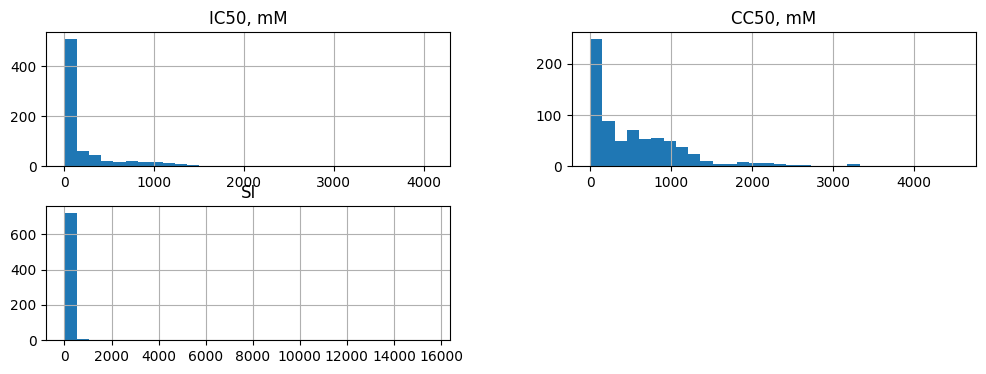

In [58]:
# изучим целевые переменные
targets = ["IC50, mM", "CC50, mM", "SI"]

y.hist(
    figsize=(12,4),
    bins=30
)

plt.show()

In [59]:
targets = ["IC50, mM", "CC50, mM", "SI"]

y[targets].describe().T

,count,mean,std,min,25%,50%,75%,max
"IC50, mM",736.0,205.703792,371.354710,0.003517,13.128758,44.000848,209.836579,4095.188563
"CC50, mM",736.0,579.275437,638.056734,0.700808,99.999036,408.793314,878.698596,4538.976189
SI,736.0,90.696738,796.808221,0.011489,1.550351,4.045156,17.247875,15620.600000


Все целевые переменные имеют широкий диапазон значений и сильно асимметричное распределение.

Для переменной IC50 медианное значение составляет 44.0, при этом максимальное значение достигает 4095.19, что свидетельствует о наличии крупных выбросов и длинного правого хвоста распределения.

Аналогичная ситуация наблюдается для CC50.

Наиболее выраженная асимметрия наблюдается у переменной SI. При медиане 4.05 максимальное значение достигает 15620.6, что говорит о наличии экстремальных выбросов и крайне неравномерном распределении.

Высокие значения стандартного отклонения для всех целевых переменных подтверждают большой разброс данных. Особенно это заметно для SI, где стандартное отклонение значительно превышает медиану.

На основании проведенного анализа можно сделать вывод, что для обучения моделей целесообразно использовать логарифмическое преобразование целевых переменных (np.log1p), поскольку оно позволяет уменьшить влияние выбросов, снизить асимметрию распределений и повысить стабильность обучения модели.

In [60]:
# определим коэффициент асимметрии распределения

y.skew()

,0
"IC50, mM",3.790165
"CC50, mM",2.071003
SI,15.477709


Анализ коэффициентов асимметрии подтвердил, что все целевые переменные имеют сильно скошенное распределение вправо. Наиболее выраженная асимметрия наблюдается у переменной SI (15.48), что свидетельствует о наличии экстремальных выбросов и длинного правого хвоста распределения. Переменные IC50 и CC50 также имеют высокие значения skewness (3.79 и 2.07 соответственно). Полученные результаты подтверждают необходимость применения логарифмического преобразования (np.log1p) перед обучением модели.


In [61]:
# Рассчитаем коэффициент асимметрии после логарифмического преобразования целевых переменных
np.log1p(y).skew()

,0
"IC50, mM",-0.056073
"CC50, mM",-0.927777
SI,1.547875


После применения логарифмического преобразования np.log1p() коэффициенты асимметрии целевых переменных значительно снизились. Для IC50 значение skewness уменьшилось с 3.79 до -0.06, для CC50 - с 2.07 до -0.93, а для SI - с 15.48 до 1.55. Это свидетельствует о существенном уменьшении асимметрии распределений и снижении влияния выбросов. Полученные результаты подтверждают целесообразность использования log-преобразования перед обучением моделей машинного обучения.


In [62]:
# проверим корреляцию целевых переменных
y.corr()

,"IC50, mM","CC50, mM",SI
"IC50, mM",1.000000,0.474213,-0.061176
"CC50, mM",0.474213,1.000000,-0.006165
SI,-0.061176,-0.006165,1.000000


Анализ корреляции показывает умеренную положительную связь между переменными IC50 и CC50 (0.47). При этом переменная SI практически не имеет линейной корреляции с остальными целевыми переменными. Полученные результаты свидетельствуют о том, что целевые переменные не являются сильно зависимыми друг от друга, поэтому для дальнейшего моделирования целесообразно использовать отдельные модели для каждой целевой переменной.

In [63]:
# логарифмическое преобразование целевых переменных
y_log = np.log1p(y)

In [64]:
from sklearn.model_selection import train_test_split

# разделяем данные на train и validation
# train - для обучения модели
# validation - для оценки качества модели
X_train, X_valid, y_train, y_valid = train_test_split(
    X_filled,
    y_log,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_valid.shape)

(588, 210)
(148, 210)


In [65]:
# Обучение baseline модели

from sklearn.ensemble import ExtraTreesRegressor

# Создаём модель ExtraTreesRegressor

model = ExtraTreesRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

# Обучаем модель
model.fit(X_train, y_train)

ExtraTreesRegressor(n_estimators=500, n_jobs=-1, random_state=42)

In [66]:
# Предсказания на validation
preds_log = model.predict(X_valid)

In [67]:
# Модель обучалась на log целевых переменных, поэтому возвращаем значения в исходный масштаб
preds = np.expm1(preds_log)

y_valid_real = np.expm1(y_valid)

In [68]:
# Оценка качества модели

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("\nМетрики качества модели:\n")

for i, col in enumerate(targets):

    # реальные значения
    y_true = y_valid_real.iloc[:, i]

    # предсказания модели
    y_pred = preds[:, i]

    # MAE
    mae = mean_absolute_error(y_true, y_pred)

    # RMSE
    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    # R2
    r2 = r2_score(y_true, y_pred)

    print(f"{col}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print("-" * 30)


Метрики качества модели:

IC50, mM
MAE  : 152.7329
RMSE : 277.9412
R2   : 0.1379
------------------------------
CC50, mM
MAE  : 307.4281
RMSE : 513.9646
R2   : 0.2727
------------------------------
SI
MAE  : 25.9011
RMSE : 102.7807
R2   : -1.2925
------------------------------


Полученные метрики свидетельствуют о крайне низкой предсказательной способности и неудовлетворительном качестве регрессионных моделей для всех трех целевых показателей. Наихудший результат наблюдается для целевой переменной SI: отрицательный коэффициент детерминации означает, что модель работает хуже простого предсказания среднего значения.

Нам необходимо дальше улучшать модель.

In [69]:
# Обучение отдельных моделей для каждой целевой переменной
X_train, X_valid, y_train_log, y_valid_log = train_test_split(
    X_filled, y_log, test_size=0.2, random_state=42
)

models = {}
print("\nМетрики качества отдельных моделей:\n")

# Обучаем отдельную модель для каждой целевой переменной
for target in targets:
    print(f"\nTarget: {target}")

    y_train = y_train_log[target]
    y_valid = y_valid_log[target]

    model = ExtraTreesRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    models[target] = model

    # Предсказания и обратное преобразование
    preds_log = model.predict(X_valid)
    preds = np.expm1(preds_log)
    y_valid_real = np.expm1(y_valid)

    # Метрики
    mae = mean_absolute_error(y_valid_real, preds)
    rmse = np.sqrt(mean_squared_error(y_valid_real, preds))
    r2 = r2_score(y_valid_real, preds)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print("-" * 30)


Метрики качества отдельных моделей:


Target: IC50, mM
MAE  : 150.9733
RMSE : 274.8874
R2   : 0.1568
------------------------------

Target: CC50, mM
MAE  : 304.2145
RMSE : 514.3227
R2   : 0.2717
------------------------------

Target: SI
MAE  : 25.6404
RMSE : 102.0971
R2   : -1.2621
------------------------------


Переход на обучение отдельных моделей для каждой целевой переменной дал небольшой, но положительный эффект для метрики IC50 (R² вырос с 0.14 до 0.15). В то же время, для SI коэффициент детерминации остался отрицательным (-1.29 и -1.26 соответственно), что означает: модель предсказывает хуже, чем простое среднее значение по выборке. Нужна доработка моделей.

In [70]:
!pip install catboost

In [71]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

cat_models = {}
print("\nОбучение CatBoost для каждой целевой переменной:\n")

for target in targets:
    print(f"Target: {target}")

    y_train = y_train_log[target]
    y_valid = y_valid_log[target]

    # Создаём модель градиентного бустинга
    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        random_state=42,
        thread_count=-1,
        verbose=False
    )

    # Обучаем с early stopping
    model.fit(
        X_train, y_train,
        eval_set=(X_valid, y_valid),
        early_stopping_rounds=50,
        use_best_model=True,
        verbose=False
    )

    cat_models[target] = model

    # Предсказания в log-пространстве
    preds_log = model.predict(X_valid)

    # Обратное преобразование в исходный масштаб
    preds = np.expm1(preds_log)
    y_valid_real = np.expm1(y_valid)

    # Метрики
    mae  = mean_absolute_error(y_valid_real, preds)
    rmse = np.sqrt(mean_squared_error(y_valid_real, preds))
    r2   = r2_score(y_valid_real, preds)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print("-" * 30)


Обучение CatBoost для каждой целевой переменной:

Target: IC50, mM
MAE  : 146.4952
RMSE : 274.5917
R2   : 0.1586
------------------------------
Target: CC50, mM
MAE  : 314.3698
RMSE : 498.3843
R2   : 0.3161
------------------------------
Target: SI
MAE  : 18.5356
RMSE : 56.0685
R2   : 0.3178
------------------------------


Применение градиентного бустинга (CatBoost) с подобранными гиперпараметрами дало существенный прогресс по всем целевым переменным: коэффициент детерминации стал положительным для каждого таргета, что означает устойчивое превосходство модели над прогнозом среднего значения.

In [72]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Целевые переменные
targets = ['IC50, mM', 'CC50, mM', 'SI']

# Отделяем признаки
drop_cols = targets + ['id']
features = [col for col in train_df.columns if col not in drop_cols]

X_train = train_df[features]
X_test = test_df[features]

# Создаем пустой DataFrame для предсказаний
submission = pd.DataFrame()

# Присваиваем индекс первой колонкой
submission['index'] = range(len(test_df))

# Обучение финальных моделей и предсказание
for target in targets:
    print(f"Обучение финальной модели для: {target}...")

    # Логарифмируем целевую переменную перед обучением (как в валидации)
    y_train_log = np.log1p(train_df[target])

    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        verbose=200,
        random_seed=42
    )

    # Обучаем на логарифмированном таргете
    model.fit(X_train, y_train_log)

    # Получаем предсказание
    preds_log = model.predict(X_test)

    # Возвращаем предсказания в исходный масштаб
    preds_real = np.expm1(preds_log)

    # Убираем из названия столбца ", mM"
    target_clean = target.replace(', mM', '')

    # Записываем корректный прогноз в колонку
    submission[target_clean] = preds_real

# Сохранение файла
submission.to_csv('submission.csv', index=False)
print("\nФайл submission.csv успешно создан!")

Обучение финальной модели для: IC50, mM...
0:	learn: 1.8084159	total: 24.3ms	remaining: 24.3s
200:	learn: 0.9676465	total: 5.56s	remaining: 22.1s
400:	learn: 0.6886870	total: 9.74s	remaining: 14.6s
600:	learn: 0.5340007	total: 20.9s	remaining: 13.8s
800:	learn: 0.4343359	total: 32.1s	remaining: 7.98s
999:	learn: 0.3625143	total: 36.3s	remaining: 0us
Обучение финальной модели для: CC50, mM...
0:	learn: 1.5593407	total: 23ms	remaining: 23s
200:	learn: 0.8341955	total: 4.3s	remaining: 17.1s
400:	learn: 0.6448100	total: 11s	remaining: 16.4s
600:	learn: 0.5405371	total: 15.8s	remaining: 10.5s
800:	learn: 0.4595011	total: 21.4s	remaining: 5.31s
999:	learn: 0.3948020	total: 25.7s	remaining: 0us
Обучение финальной модели для: SI...
0:	learn: 1.4689687	total: 21.8ms	remaining: 21.7s
200:	learn: 0.9189920	total: 4.24s	remaining: 16.9s
400:	learn: 0.7260187	total: 10s	remaining: 15s
600:	learn: 0.6105819	total: 14.3s	remaining: 9.47s
800:	learn: 0.5350397	total: 18.7s	remaining: 4.64s
999:	learn:

In [ ]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Заново разделяем данные
X_train, X_valid, y_train_log, y_valid_log = train_test_split(
    X_filled, y_log, test_size=0.2, random_state=42
)

rf_models = {}
print("\nОбучение RandomForest для каждой целевой переменной:\n")

for target in targets:
    print(f"Target: {target}")

    y_train = y_train_log[target]
    y_valid = y_valid_log[target]

    # Создаём модель случайного леса
    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )

    # Обучаем модель
    model.fit(X_train, y_train)

    rf_models[target] = model

    # Предсказания в log-пространстве
    preds_log = model.predict(X_valid)

    # Обратное преобразование в исходный масштаб
    preds = np.expm1(preds_log)
    y_valid_real = np.expm1(y_valid)

    # Метрики
    mae  = mean_absolute_error(y_valid_real, preds)
    rmse = np.sqrt(mean_squared_error(y_valid_real, preds))
    r2   = r2_score(y_valid_real, preds)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print("-" * 30)


Обучение RandomForest для каждой целевой переменной:

Target: IC50, mM
MAE  : 147.3666
RMSE : 275.9560
R2   : 0.1502
------------------------------
Target: CC50, mM
MAE  : 322.7713
RMSE : 520.2466
R2   : 0.2548
------------------------------
Target: SI
MAE  : 19.7986
RMSE : 57.9567
R2   : 0.2711
------------------------------


Обучение моделей RandomForest показало немного более скромные результаты по сравнению с градиентным бустингом (CatBoost), т.к. для всех трёх целевых переменных коэффициент детерминации оказался чуть ниже

In [74]:
!pip install xgboost

In [75]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Заново разделяем данные
X_train, X_valid, y_train_log, y_valid_log = train_test_split(
    X_filled, y_log, test_size=0.2, random_state=42
)

xgb_models = {}
print("\nОбучение XGBoost для каждой целевой переменной:\n")

for target in targets:
    print(f"Target: {target}")

    y_train = y_train_log[target]
    y_valid = y_valid_log[target]

    model = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror',
        eval_metric='rmse',
        early_stopping_rounds=50
    )


    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False
    )

    xgb_models[target] = model

    # Предсказания и обратное преобразование
    preds_log = model.predict(X_valid)
    preds = np.expm1(preds_log)
    y_valid_real = np.expm1(y_valid.to_numpy())

    # Метрики
    mae  = mean_absolute_error(y_valid_real, preds)
    rmse = np.sqrt(mean_squared_error(y_valid_real, preds))
    r2   = r2_score(y_valid_real, preds)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print("-" * 30)


Обучение XGBoost для каждой целевой переменной:

Target: IC50, mM
MAE  : 150.2256
RMSE : 282.3030
R2   : 0.1106
------------------------------
Target: CC50, mM
MAE  : 323.9429
RMSE : 529.6503
R2   : 0.2276
------------------------------
Target: SI
MAE  : 18.5370
RMSE : 54.8852
R2   : 0.3463
------------------------------


Модель XGBoost продемонстрировала смешанные результаты по сравнению с CatBoost: для переменной SI качество прогноза улучшилось, на что указывает рост метрики R2 до 0.3463 и снижение ошибки RMSE, однако для показателей IC50 и CC50 точность предсказаний заметно снизилась

In [76]:
# удалим константные признаки
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X_var = selector.fit_transform(X_filled)

selected_columns = X_filled.columns[selector.get_support()]

X_var = pd.DataFrame(X_var, columns=selected_columns)

In [77]:
# удалим сильно коррелирующие признаки

corr_matrix = X_var.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

X_corr = X_var.drop(columns=to_drop)

print("Удалено:", len(to_drop))
print("Осталось:", X_corr.shape[1])

Удалено: 33
Осталось: 144


In [79]:
y = y_log[[
    "IC50, mM",
    "CC50, mM",
    "SI"
]]

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_corr,
    y,
    test_size=0.2,
    random_state=42
)

In [81]:
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

base_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model = MultiOutputRegressor(base_model)

model.fit(X_train, y_train)

pred = model.predict(X_test)

from sklearn.metrics import r2_score

r2_scores = r2_score(
    y_test,
    pred,
    multioutput='raw_values'
)

targets = [
    "IC50, mM",
    "CC50, mM",
    "SI"
]

for i, target in enumerate(targets):

    print(target)
    print("R² =", round(r2_scores[i], 4))
    print()

IC50, mM
R² = 0.3516

CC50, mM
R² = 0.4519

SI
R² = 0.2699



После очистки признаков показатели коэффициента детерминации улучшились для IC50 и CC50

In [82]:
# feature importance
importances = np.mean(
    [est.feature_importances_
     for est in model.estimators_],
    axis=0
)

importance_df = pd.DataFrame({
    "feature": X_corr.columns,
    "importance": importances
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df.head(20)

,feature,importance
92,NumSaturatedHeterocycles,0.035860
91,NumSaturatedCarbocycles,0.035512
81,NHOHCount,0.025414
85,NumAliphaticRings,0.025347
94,RingCount,0.022626
106,fr_NH1,0.022225
96,fr_Al_COO,0.017851
139,fr_sulfonamd,0.017560
78,VSA_EState8,0.016231
141,fr_thiazole,0.015416


In [94]:
top_features = importance_df.head(100)["feature"]

X_selected = X_corr[top_features]

print(X_selected.shape)

(736, 100)


In [95]:
from sklearn.model_selection import train_test_split

y = y_log[[
    "IC50, mM",
    "CC50, mM",
    "SI"
]]

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

In [96]:
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

base_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=3,
    random_state=42
)

model = MultiOutputRegressor(base_model)

model.fit(X_train, y_train)

MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.03, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=4,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=500, n_jobs=None,
                                            num_parallel_tree=None, ...))

In [97]:
from sklearn.metrics import r2_score

pred = model.predict(X_test)

r2_scores = r2_score(
    y_test,
    pred,
    multioutput='raw_values'
)

targets = [
    "IC50, mM",
    "CC50, mM",
    "SI"
]

for i, target in enumerate(targets):

    print(target)
    print("R² =", round(r2_scores[i], 4))
    print()

IC50, mM
R² = 0.3874

CC50, mM
R² = 0.4486

SI
R² = 0.2822



In [98]:
from catboost import CatBoostRegressor
from sklearn.multioutput import MultiOutputRegressor

In [99]:
base_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    eval_metric='R2',
    verbose=100,
    random_state=42
)

model = MultiOutputRegressor(base_model)

In [100]:
model.fit(X_train, y_train)

pred = model.predict(X_test)

0:	learn: 0.0120232	total: 23.9ms	remaining: 23.9s
100:	learn: 0.5415149	total: 1.26s	remaining: 11.2s
200:	learn: 0.6540000	total: 4.03s	remaining: 16s
300:	learn: 0.7232161	total: 8.16s	remaining: 19s
400:	learn: 0.7844444	total: 11.4s	remaining: 17s
500:	learn: 0.8255816	total: 14.2s	remaining: 14.2s
600:	learn: 0.8529240	total: 16s	remaining: 10.6s
700:	learn: 0.8708599	total: 17.2s	remaining: 7.36s
800:	learn: 0.8851575	total: 19.1s	remaining: 4.74s
900:	learn: 0.8961229	total: 21.1s	remaining: 2.31s
999:	learn: 0.9034468	total: 22.3s	remaining: 0us
0:	learn: 0.0134678	total: 15ms	remaining: 14.9s
100:	learn: 0.5166157	total: 1.26s	remaining: 11.2s
200:	learn: 0.6308047	total: 2.49s	remaining: 9.91s
300:	learn: 0.6960250	total: 3.71s	remaining: 8.61s
400:	learn: 0.7447472	total: 4.98s	remaining: 7.44s
500:	learn: 0.7752752	total: 6.23s	remaining: 6.2s
600:	learn: 0.7934601	total: 7.47s	remaining: 4.96s
700:	learn: 0.8074331	total: 9.1s	remaining: 3.88s
800:	learn: 0.8177803	total:

In [101]:
from sklearn.metrics import r2_score

r2_scores = r2_score(
    y_test,
    pred,
    multioutput='raw_values'
)

targets = [
    "IC50, mM",
    "CC50, mM",
    "SI"
]

for i, target in enumerate(targets):

    print(target)
    print("R² =", round(r2_scores[i], 4))
    print()

IC50, mM
R² = 0.3696

CC50, mM
R² = 0.4743

SI
R² = 0.235



Наилучшие результаты показала модель XGBoost. После отбора top-100 наиболее значимых признаков удалось получить следующие значения коэффициента детерминации R²:

- IC50: 0.3874

- CC50: 0.4486

- SI: 0.2822

Поэтому в качестве финальной модели для генерации предсказаний и создания submission-файла я выбираю именно эту модель

In [102]:

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')


targets = ['IC50, mM', 'CC50, mM', 'SI']


drop_cols = targets + ['id']

features = [
    col for col in train_df.columns
    if col not in drop_cols
]

X_train_full = train_df[features]
X_test_full = test_df[features]


X_train_full = X_train_full.fillna(
    X_train_full.median()
)

X_test_full = X_test_full.fillna(
    X_train_full.median()
)


X_train_var = X_train_full[selected_columns]

X_test_var = X_test_full[selected_columns]


X_train_corr = X_train_var.drop(
    columns=to_drop,
    errors='ignore'
)

X_test_corr = X_test_var.drop(
    columns=to_drop,
    errors='ignore'
)


X_train_selected = X_train_corr[top_features]

X_test_selected = X_test_corr[top_features]



submission = pd.DataFrame()

submission['index'] = range(len(test_df))

# Обучение и предсказание

from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

# логарифмируем целевые признаки
y_train = np.log1p(train_df[targets])

# модель
base_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=3,
    random_state=42
)

model = MultiOutputRegressor(base_model)

# обучение
model.fit(X_train_selected, y_train)

# predict
pred_log = model.predict(X_test_selected)

pred_real = np.expm1(pred_log)


submission['IC50'] = pred_real[:, 0]
submission['CC50'] = pred_real[:, 1]
submission['SI'] = pred_real[:, 2]


submission.to_csv(
    'submission.csv',
    index=False
)

print("\nФайл submission.csv успешно создан!")


Файл submission.csv успешно создан!


In [103]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>